Sorted edges by weight:
(2, 8, 2)
(5, 6, 2)
(0, 1, 4)
(2, 5, 4)
(6, 8, 6)
(2, 3, 7)
(7, 8, 7)
(0, 7, 8)
(1, 2, 8)
(3, 4, 9)
(4, 5, 10)
(1, 7, 11)
(3, 5, 14)

Step-by-step Kruskal process:

Adding edge (2, 8) with weight 2
Adding edge (5, 6) with weight 2
Adding edge (0, 1) with weight 4
Adding edge (2, 5) with weight 4
Skipping edge (6, 8) with weight 6 – forms cycle
Adding edge (2, 3) with weight 7
Adding edge (7, 8) with weight 7
Adding edge (0, 7) with weight 8
Skipping edge (1, 2) with weight 8 – forms cycle
Adding edge (3, 4) with weight 9
Skipping edge (4, 5) with weight 10 – forms cycle
Skipping edge (1, 7) with weight 11 – forms cycle
Skipping edge (3, 5) with weight 14 – forms cycle

Final MST edges:
(2, 8, 2)
(5, 6, 2)
(0, 1, 4)
(2, 5, 4)
(2, 3, 7)
(7, 8, 7)
(0, 7, 8)
(3, 4, 9)

Total MST Weight: 43


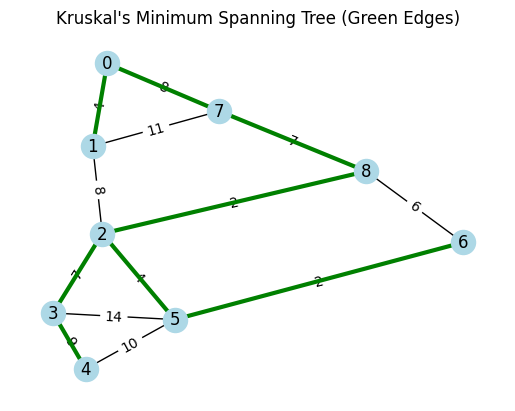

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Kruskal’s Algorithm – Manual Implementation class
class UnionFind:
    def __init__(self, nodes):
        self.parent = {node: node for node in nodes}

    def find(self, node):
        if self.parent[node] != node:
            self.parent[node] = self.find(self.parent[node])
        return self.parent[node]

    def union(self, u, v):
        root_u = self.find(u)
        root_v = self.find(v)
        if root_u != root_v:
            self.parent[root_v] = root_u
            return True
        return False

# Create Graph
G = nx.Graph()
edges = [
    (0, 1, 4), (0, 7, 8), (1, 7, 11),
    (1, 2, 8), (2, 8, 2), (2, 5, 4),
    (2, 3, 7), (3, 4, 9), (3, 5, 14),
    (4, 5, 10), (5, 6, 2), (6, 8, 6),
    (7, 8, 7)
]
G.add_weighted_edges_from(edges)

# Sort edges by weight for Kruskal's algorithm
sorted_edges = sorted(edges, key=lambda x: x[2])

print("Sorted edges by weight:")
for e in sorted_edges:
    print(e)

# STEP 2: Initialize UnionFind
uf = UnionFind(G.nodes())
MST = []
total_weight = 0

print("\nStep-by-step Kruskal process:\n")
# STEP 3: Pick edges in sorted order
for u, v, w in sorted_edges:
    if uf.union(u, v):
        MST.append((u, v, w))
        total_weight += w
        print(f"Adding edge ({u}, {v}) with weight {w}")
    else:
        print(f"Skipping edge ({u}, {v}) with weight {w} – forms cycle")

print("\nFinal MST edges:")
for edge in MST:
    print(edge)
print(f"\nTotal MST Weight: {total_weight}")

# Visualization
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_color="lightblue")
nx.draw_networkx_edge_labels(G, pos,
edge_labels=nx.get_edge_attributes(G, 'weight'))

# Highlight MST
mst_graph = nx.Graph()
mst_graph.add_weighted_edges_from(MST)
nx.draw_networkx_edges(mst_graph, pos, edge_color="green", width=3)
plt.title("Kruskal's Minimum Spanning Tree (Green Edges)")
plt.axis("off")
plt.show()


Prim's Algorithm Results:
Final MST edges:
(0, 1, 4)
(0, 7, 8)
(7, 8, 7)
(8, 2, 2)
(2, 5, 4)
(5, 6, 2)
(2, 3, 7)
(3, 4, 9)

Total MST Weight: 43


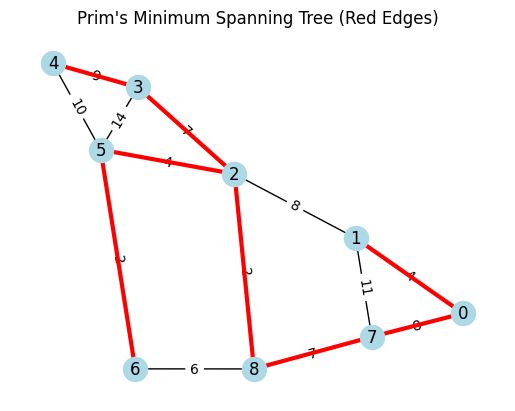

In [4]:
# prims algorithm
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Manual Implementation of Prim's Algorithm
def prims_mst(graph, start_node):
    min_heap = []
    visited = set()
    mst_edges = []
    total_weight = 0

    # Start with the initial node
    visited.add(start_node)
    for neighbor, attrs in graph[start_node].items():
        heapq.heappush(min_heap, (attrs['weight'], start_node, neighbor))

    while min_heap:
        weight, u, v = heapq.heappop(min_heap)
        if v not in visited:
            visited.add(v)
            mst_edges.append((u, v, weight))
            total_weight += weight

            # Add neighbors of newly visited node
            for neighbor_of_v, attrs_of_v in graph[v].items():
                if neighbor_of_v not in visited:
                    heapq.heappush(min_heap, (attrs_of_v['weight'], v, neighbor_of_v))

    return mst_edges, total_weight

# Create Graph
G_prim = nx.Graph()
edges_prim = [
    (0, 1, {"weight": 4}), (0, 7, {"weight": 8}),
    (1, 7, {"weight": 11}), (1, 2, {"weight": 8}),
    (2, 8, {"weight": 2}), (2, 5, {"weight": 4}),
    (2, 3, {"weight": 7}), (3, 4, {"weight": 9}),
    (3, 5, {"weight": 14}), (4, 5, {"weight": 10}),
    (5, 6, {"weight": 2}), (6, 8, {"weight": 6}),
    (7, 8, {"weight": 7})
]
G_prim.add_edges_from(edges_prim)

# Run Prim's Algorithm
start_node = 0
mst_edges_prim, total_weight_prim = prims_mst(G_prim, start_node)

print("\nPrim's Algorithm Results:")
print("Final MST edges:")
for edge in mst_edges_prim:
    print(edge)
print(f"\nTotal MST Weight: {total_weight_prim}")

# Visualization
pos_prim = nx.spring_layout(G_prim)
nx.draw_networkx(G_prim, pos_prim, with_labels=True, node_color="lightblue")
nx.draw_networkx_edge_labels(G_prim, pos_prim, edge_labels=nx.get_edge_attributes(G_prim, 'weight'))

# Highlight MST
mst_graph_prim = nx.Graph()
mst_graph_prim.add_weighted_edges_from(mst_edges_prim)
nx.draw_networkx_edges(mst_graph_prim, pos_prim, edge_color="red", width=3)
plt.title("Prim's Minimum Spanning Tree (Red Edges)")
plt.axis("off")
plt.show()